In [1]:
#==================================================
# Imports
#==================================================
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray
import datetime
import calendar
import matplotlib
import os
#import h5py
import PseudoNetCDF as pnc
from scipy.ndimage import label
import scipy.interpolate as interp
import pickle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.gridspec as gridspec
from scipy.integrate import cumulative_trapezoid as scitrapz
import scipy

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
#=======================================
# Diagnostics Parameters
#=======================================
space = '    '
#=======================================
# Functions
#=======================================
def print_diag(key,var):
    print(key)
    print(space,'Shape:',np.shape(var))
    print(space,'Max:',np.max(var))
    print(space,'Min:',np.min(var))
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx],idx

# Read in Learjet ice cloud pass dictionary

In [10]:
path = '/pscratch/sd/m/mckenna/learjet/20190925/cloud_passes/'
file = path+'camp2ex_learjet_20190925_cloud_pass_dict_ice.p'
learjet_dict = pickle.load(open(file,"rb"))


lj_mean_temps = []
lj_min_temps = []
lj_max_temps = []
lj_mean_w = []
lj_std_w = []
lj_max_w = []
lj_min_w = []
lj_keys = []
lj_mean_lwc = []
lj_max_lwc = []
lj_mean_twc = []
lj_max_twc = []
lj_mean_iwc = []
lj_max_iwc = []
lj_transect_length = []
lj_cloud_pass_id = []
lj_mean_alts = []
lj_samp_size = []

for key in learjet_dict.keys():
    tmp_mean_temp = learjet_dict[key]['bulk_dict']['mean_temp']
    tmp_min_temp = learjet_dict[key]['bulk_dict']['min_temp']
    tmp_max_temp = learjet_dict[key]['bulk_dict']['max_temp']
    tmp_mean_w = learjet_dict[key]['bulk_dict']['mean_w']
    tmp_mean_alts = np.mean(learjet_dict[key]['bulk_dict']['alt'])
    tmp_max_w = learjet_dict[key]['bulk_dict']['max_w']
    tmp_min_w = learjet_dict[key]['bulk_dict']['min_w']
    tmp_w = learjet_dict[key]['bulk_dict']['w']
    tmp_std_w = np.std(tmp_w)
    lj_std_w.append(tmp_std_w)
    tmp_mean_lwc = learjet_dict[key]['bulk_dict']['mean_NevLWC']
    tmp_mean_twc = learjet_dict[key]['bulk_dict']['mean_NevTWC']
    tmp_max_lwc = learjet_dict[key]['bulk_dict']['max_NevLWC']
    tmp_max_twc = learjet_dict[key]['bulk_dict']['max_NevTWC']
    tmp_tas = learjet_dict[key]['bulk_dict']['tas'] # m/s
    len_transect = np.sum(tmp_tas)*1.e-3 # since each sample is 1 second, only need to to sum to ket transect length and then convert to km for convenience
    lj_transect_length.append(np.sum(len_transect))
    lj_samp_size.append(len(tmp_tas))
    tmp_lwc = learjet_dict[key]['bulk_dict']['NevLWC']
    tmp_twc = learjet_dict[key]['bulk_dict']['NevTWC']
    tmp_iwc = tmp_twc - tmp_lwc
    tmp_mean_iwc = np.nanmean(tmp_iwc)
    tmp_max_iwc = np.nanmax(tmp_iwc)
    tmp_min_iwc = np.nanmin(tmp_iwc)
    
    lj_mean_temps.append(tmp_mean_temp)
    lj_min_temps.append(tmp_mean_temp)
    lj_max_temps.append(tmp_mean_temp)
    lj_mean_alts.append(tmp_mean_alts)
    lj_mean_w.append(tmp_mean_w)
    lj_std_w.append(tmp_std_w)
    lj_max_w.append(tmp_max_w)
    lj_min_w.append(tmp_min_w)
    lj_mean_lwc.append(tmp_mean_lwc)
    lj_mean_twc.append(tmp_mean_twc)
    lj_mean_iwc.append(tmp_mean_iwc)
    lj_max_lwc.append(tmp_max_lwc)
    lj_max_twc.append(tmp_max_twc)
    lj_max_iwc.append(tmp_max_iwc)
    lj_keys.append(key)
    lj_cloud_pass_id.append(int(key))
    

lj_mean_temps = np.array(lj_mean_temps)
lj_max_temps = np.array(lj_max_temps)
lj_min_temps = np.array(lj_min_temps)
lj_mean_alts = np.array(lj_mean_alts)
lj_mean_w = np.array(lj_mean_w)
lj_max_w = np.array(lj_max_w)
lj_std_w = np.array(lj_std_w)
lj_min_w = np.array(lj_min_w)
lj_mean_lwc = np.array(lj_mean_lwc)
lj_mean_twc = np.array(lj_mean_twc)
lj_mean_iwc = np.array(lj_mean_iwc)
lj_max_lwc = np.array(lj_max_lwc)
lj_max_twc = np.array(lj_max_twc)
lj_max_iwc = np.array(lj_max_iwc)
lj_transect_length = np.array(lj_transect_length)
lj_cloud_pass_id = np.array(lj_cloud_pass_id)
lj_samp_size = np.array(lj_samp_size)

# Read in P3 ice cloud pass dictionary

In [11]:
path = '/pscratch/sd/m/mckenna/p3/20190925/cloud_passes/'
file = path+'camp2ex_p3_20190925_cloud_pass_dict_ice.p'
p3_dict = pickle.load(open(file,"rb"))


p3_mean_temps = []
p3_min_temps = []
p3_max_temps = []
p3_mean_w = []
p3_std_w = []
p3_max_w = []
p3_min_w = []
p3_keys = []
p3_mean_lwc = []
p3_max_lwc = []
p3_mean_twc = []
p3_max_twc = []
p3_mean_iwc = []
p3_max_iwc = []
p3_transect_length = []
p3_cloud_pass_id = []
p3_mean_alts = []
p3_samp_size = []

for i,key in enumerate(p3_dict.keys()):
    if i != 11:
        continue
    tmp_mean_temp = p3_dict[key]['bulk_dict']['mean_temp']
    tmp_min_temp = p3_dict[key]['bulk_dict']['min_temp']
    tmp_max_temp = p3_dict[key]['bulk_dict']['max_temp']
    tmp_mean_w = p3_dict[key]['bulk_dict']['mean_w']
    tmp_mean_alts = np.mean(p3_dict[key]['bulk_dict']['alt'])
    tmp_max_w = p3_dict[key]['bulk_dict']['max_w']
    tmp_min_w = p3_dict[key]['bulk_dict']['min_w']
    tmp_w = p3_dict[key]['bulk_dict']['w']
    tmp_std_w = np.std(tmp_w)
    p3_std_w.append(tmp_std_w)
    #tmp_mean_lwc = p3_dict[key]['bulk_dict']['mean_NevLWC']
    #tmp_mean_twc = p3_dict[key]['bulk_dict']['mean_NevTWC']
    #tmp_max_lwc = p3_dict[key]['bulk_dict']['max_NevLWC']
    #tmp_max_twc = p3_dict[key]['bulk_dict']['max_NevTWC']
    tmp_tas = p3_dict[key]['bulk_dict']['tas'] # m/s
    len_transect = np.sum(tmp_tas)*1.e-3 # since each sample is 1 second, only need to to sum to ket transect length and then convert to km for convenience
    p3_transect_length.append(np.sum(len_transect))
    p3_samp_size.append(len(tmp_tas))
    #tmp_lwc = p3_dict[key]['bulk_dict']['NevLWC']
    #tmp_twc = p3_dict[key]['bulk_dict']['NevTWC']
    tmp_iwc = tmp_twc - tmp_lwc
    tmp_mean_iwc = np.nanmean(tmp_iwc)
    tmp_max_iwc = np.nanmax(tmp_iwc)
    tmp_min_iwc = np.nanmin(tmp_iwc)
    
    p3_mean_temps.append(tmp_mean_temp)
    p3_min_temps.append(tmp_min_temp)
    p3_max_temps.append(tmp_max_temp)
    p3_mean_alts.append(tmp_mean_alts)
    p3_mean_w.append(tmp_mean_w)
    p3_std_w.append(tmp_std_w)
    p3_max_w.append(tmp_max_w)
    p3_min_w.append(tmp_min_w)
    #p3_mean_lwc.append(tmp_mean_lwc)
    #p3_mean_twc.append(tmp_mean_twc)
    #p3_mean_iwc.append(tmp_mean_iwc)
    #p3_max_lwc.append(tmp_max_lwc)
    #p3_max_twc.append(tmp_max_twc)
    #p3_max_iwc.append(tmp_max_iwc)
    p3_keys.append(key)
    p3_cloud_pass_id.append(i)
    

p3_mean_temps = np.array(p3_mean_temps)
p3_max_temps = np.array(p3_max_temps)
p3_min_temps = np.array(p3_min_temps)
p3_mean_alts = np.array(p3_mean_alts)
p3_mean_w = np.array(p3_mean_w)
p3_max_w = np.array(p3_max_w)
p3_std_w = np.array(p3_std_w)
p3_min_w = np.array(p3_min_w)
#p3_mean_lwc = np.array(p3_mean_lwc)
#p3_mean_twc = np.array(p3_mean_twc)
#p3_mean_iwc = np.array(p3_mean_iwc)
#p3_max_lwc = np.array(p3_max_lwc)
#p3_max_twc = np.array(p3_max_twc)
#p3_max_iwc = np.array(p3_max_iwc)
p3_transect_length = np.array(p3_transect_length)
p3_cloud_pass_id = np.array(p3_cloud_pass_id)
p3_samp_size = np.array(p3_samp_size)

In [12]:
# ---------------------------------------------------------------
# Combine LJ (4 passes) and P3 (1 pass) into unified obs_* arrays
# P3 has no LWC/IWC/TWC from the Nevzorov probe → set to NaN
# ---------------------------------------------------------------
n_p3 = len(p3_mean_temps)   # = 1

obs_mean_temps  = np.concatenate([lj_mean_temps,  p3_mean_temps])
obs_min_temps   = np.concatenate([lj_min_temps,   p3_min_temps])
obs_max_temps   = np.concatenate([lj_max_temps,   p3_max_temps])
obs_mean_alts   = np.concatenate([lj_mean_alts,   p3_mean_alts])
obs_mean_w      = np.concatenate([lj_mean_w,      p3_mean_w])
obs_std_w       = np.concatenate([lj_std_w,       p3_std_w])
obs_max_w       = np.concatenate([lj_max_w,       p3_max_w])
obs_min_w       = np.concatenate([lj_min_w,       p3_min_w])
obs_transect_length = np.concatenate([lj_transect_length, p3_transect_length])
obs_samp_size   = np.concatenate([lj_samp_size,   p3_samp_size])

# LWC / IWC / TWC only available from LJ Nevzorov probe
obs_mean_lwc = np.concatenate([lj_mean_lwc, np.full(n_p3, np.nan)])
obs_max_lwc  = np.concatenate([lj_max_lwc,  np.full(n_p3, np.nan)])
obs_mean_twc = np.concatenate([lj_mean_twc, np.full(n_p3, np.nan)])
obs_max_twc  = np.concatenate([lj_max_twc,  np.full(n_p3, np.nan)])
obs_mean_iwc = np.concatenate([lj_mean_iwc, np.full(n_p3, np.nan)])
obs_max_iwc  = np.concatenate([lj_max_iwc,  np.full(n_p3, np.nan)])

# String keys: LJ uses its integer key, P3 uses 'p3'
obs_cloud_pass_keys = [str(x) for x in lj_cloud_pass_id] + ['p3']

# --- Sort all obs arrays from warmest to coldest ---
sort_idx = np.argsort(obs_mean_temps)[::-1]

obs_mean_temps      = obs_mean_temps[sort_idx]
obs_min_temps       = obs_min_temps[sort_idx]
obs_max_temps       = obs_max_temps[sort_idx]
obs_mean_alts       = obs_mean_alts[sort_idx]
obs_mean_w          = obs_mean_w[sort_idx]
obs_std_w           = obs_std_w[sort_idx]
obs_max_w           = obs_max_w[sort_idx]
obs_min_w           = obs_min_w[sort_idx]
obs_transect_length = obs_transect_length[sort_idx]
obs_samp_size       = obs_samp_size[sort_idx]
obs_mean_lwc        = obs_mean_lwc[sort_idx]
obs_max_lwc         = obs_max_lwc[sort_idx]
obs_mean_twc        = obs_mean_twc[sort_idx]
obs_max_twc         = obs_max_twc[sort_idx]
obs_mean_iwc        = obs_mean_iwc[sort_idx]
obs_max_iwc         = obs_max_iwc[sort_idx]
obs_cloud_pass_keys = [obs_cloud_pass_keys[i] for i in sort_idx]

print('Obs cloud pass keys (warm→cold):', obs_cloud_pass_keys)
print('Obs mean temps:', obs_mean_temps)

Obs cloud pass keys (warm→cold): ['19', '21', '20', 'p3', '22', '23']
Obs mean temps: [  1.03636364  -7.275       -7.425      -11.0936     -14.57083333
 -14.75555556]


# Grab the DHARMA Bin simulation 3D files and grab individual files at 10-minute increments between hours 6 & 12 that emulate the observed cloud passes

In [123]:
#sim_name = 'sip_10x_bin_ice'
#cap_sim_name = 'SIP 10X'

#sim_name = 'sip_10x_bin_ice_noturb'
#cap_sim_name = 'SIP 10X NOTURB'

#sim_name = 'sip_bin_ice'
#cap_sim_name = 'SIP'

sim_name = 'sip_bin_ice_noturb'
cap_sim_name = 'SIP NOTURB'

#sim_name = 'cntl_bin_ice'
#cap_sim_name = 'CNTL'

#sim_name = 'cntl_bin_ice_noturb'
#cap_sim_name = 'CNTL NOTURB'

path = '/pscratch/sd/m/mckenna/dharma_3d/'+sim_name+'/'
files = sorted(glob.glob(path+'dharma_3d*.nc'))#[::10]
print(files)

['/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_021600.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_022200.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_022800.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_023400.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_024000.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_024600.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_025200.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_025800.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_026400.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_027000.nc', '/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma

# Read in 3D files and construct 4D arrays (added time dimension)
## 5D arrays are also constructed where the 5th dimension is the 50 size bins for the number concentration

In [124]:
time = []
ql = []
qi = []
qnl = []
qni = []
rho = []
w = []
temp = []
nr_liq = []
nr_ice = []

dumi=1
dum_init = True
for file in files:
    print(file)
    ncfile = xarray.open_dataset(file,decode_times=False)
    time.append(ncfile['time'].values)
    #ql.append(ncfile['ql'].values)
    #qi.append(ncfile['qi'].values)
    #qnl.append(ncfile['nl'].values)
    #qni.append(ncfile['ni'].values)
    #rho.append(ncfile['rhobar'].values)
    #w.append(ncfile['w_interp'].values)
    #temp.append(ncfile['temperature'].values-273.15)

    tmp_ql = ncfile['ql'].values
    tmp_qi = ncfile['qi'].values
    tmp_qnl = ncfile['nl'].values
    tmp_qni = ncfile['ni'].values
    tmp_rho = ncfile['rhobar'].values
    tmp_w = ncfile['w_interp'].values
    tmp_temp = ncfile['temperature'].values-273.15
    mean_temp = np.mean(tmp_temp,axis=(0,1))
    if dum_init:
        dumid = np.where( (mean_temp <= 0) & (mean_temp >= -20) )[0]
        dum_init = False

    tmp_w = tmp_w[:,:,dumid]
    tmp_ql = tmp_ql[:,:,dumid]
    tmp_qi = tmp_qi[:,:,dumid]
    tmp_qnl = tmp_qnl[:,:,dumid]
    tmp_qni = tmp_qni[:,:,dumid]
    tmp_rho = tmp_rho[dumid]
    tmp_temp = tmp_temp[:,:,dumid]
    mean_temp = mean_temp[dumid]

        
    ql.append(tmp_ql)
    qi.append(tmp_qi)
    qnl.append(tmp_qnl)
    qni.append(tmp_qni)
    w.append(tmp_w)
    temp.append(tmp_temp)
    rho.append(tmp_rho)

    if dumi==1:
        x = ncfile['x'].values
        y = ncfile['y'].values
        z = ncfile['zt'].values
        z = z[dumid]
        pc_rbound = ncfile['pc_rbound_02'].values
        pc_rbound_ice = ncfile['pc_rbound_03'].values
        pc_radius = ncfile['pc_radius_02'].values
        pc_radius_ice = ncfile['pc_radius_03'].values
        dumi=0
    liq_num_dict = {}
    ice_num_dict = {}

    tmp_keys = list(ncfile.keys())

    tmp_nr_liq = []
    tmp_nr_ice = []
    for tmp_key in tmp_keys:
        if 'liq_num' in tmp_key:
            tmp_tmp_nr_liq = ncfile[tmp_key].values[:,:,dumid]
            tmp_nr_liq.append(tmp_tmp_nr_liq)
        if 'ice_num' in tmp_key:
            tmp_tmp_nr_ice = ncfile[tmp_key].values[:,:,dumid]
            tmp_nr_ice.append(tmp_tmp_nr_ice)
            
    tmp_nr_liq = np.array(tmp_nr_liq)
    tmp_nr_ice = np.array(tmp_nr_ice)
    nr_liq.append(tmp_nr_liq)
    nr_ice.append(tmp_nr_ice)
    
ncfile.close()
        
time = np.array(time)
ql = np.array(ql)
qi = np.array(qi)
qt = ql + qi
qnl = np.array(qnl)
qni = np.array(qni)
qnt = qnl + qni
w = np.array(w)
temp = np.array(temp)
rho = np.array(rho)
nr_liq = np.array(nr_liq) # units are #/g
nr_liq = nr_liq*rho[0,:]*1.e3*1.e-6 # /cc
nr_ice = np.array(nr_ice) # units are #/g
nr_ice = nr_ice*rho[0,:]*1.e3*1.e-6 # /cc
lwc = ql*rho[0,:]*1.e3
iwc = qi*rho[0,:]*1.e3
twc = (ql+qi)*rho[0,:]*1.e3
#nr = nr_liq + nr_ice

/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_021600.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_022200.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_022800.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_023400.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_024000.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_024600.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_025200.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_025800.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_026400.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_027000.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_bin_ice_noturb/dharma_3d_sip_bin_ice_noturb_027600.nc

In [125]:
import numpy as np
from scipy.interpolate import interp1d

def interp_bins(nr, r_native, r_new):
    """
    nr        : (..., nbin, ...)
    r_native  : (nbin,)
    r_new     : (nnew,)
    returns   : (..., nnew, ...)
    """

    # Move radius dimension to last for clean interpolation
    nr_swap = np.moveaxis(nr, 1, -1)   # (..., nbin)

    f = interp1d(
        r_native,
        nr_swap,
        axis=-1,
        kind='linear',
        bounds_error=False,
        fill_value=0.0,
        assume_sorted=True
    )

    nr_interp = f(r_new)  # (..., nnew)

    # Move radius back to original position
    return np.moveaxis(nr_interp, -1, 1)


In [126]:
#pc_radius_interp = np.arange(1.0, 8906.0, 1.0)  # microns
pc_radius_interp = np.concatenate([np.arange(1.0, 101., 1.0),np.arange(105,1005,5),np.arange(1050,9000,50)])  # microns

# Bin edges for the common grid (midpoints between adjacent centers, extended at boundaries)
_dr = np.diff(pc_radius_interp)
pc_rbound_interp = np.concatenate([[pc_radius_interp[0] - _dr[0]/2],
                                    (pc_radius_interp[:-1] + pc_radius_interp[1:]) / 2,
                                    [pc_radius_interp[-1] + _dr[-1]/2]])
n_interp = pc_radius_interp.size

# Bin widths on each native grid (diameter in microns)
dD_liq    = np.diff(pc_rbound * 2)          # (nbin_liq,)
dD_ice    = np.diff(pc_rbound_ice * 2)      # (nbin_ice,)
dD_common = np.diff(pc_rbound_interp * 2)   # (n_interp,)

In [127]:
def make_cloud_pass_dict_y(var_dict,target_obs_temp):
    nx = len(var_dict['x'])
    ny = len(var_dict['y'])
    nt = len(var_dict['lwc'][:,0,0,0])

    cloud_pass_dict_y = {}
    cp_counter=1
    
    for tt in range(nt):
        mean_temp_prof = np.mean(var_dict['temp'][tt,:,:,:],axis=(0,1))
        nearest_val,nearest_id = find_nearest(mean_temp_prof,target_obs_temp)
        nearest_z = var_dict['z'][nearest_id]*1.e-3
        
        tmp_lwc = var_dict['lwc'][tt,:,:,nearest_id].T
        tmp_iwc = var_dict['iwc'][tt,:,:,nearest_id].T
        tmp_twc = var_dict['twc'][tt,:,:,nearest_id].T
        tmp_w = var_dict['w'][tt,:,:,nearest_id].T
        #tmp_nr = var_dict['nr'][tt,:,:,:,nearest_id].T
        tmp_nr_liq = var_dict['nr_liq'][tt,:,:,:,nearest_id].T
        tmp_nr_ice = var_dict['nr_ice'][tt,:,:,:,nearest_id].T
        tmp_rho = var_dict['rho'][tt,nearest_id]

        vec_mask = np.zeros((nx,ny))
        for ii in range(nx):
            tmp_vec_mask = np.zeros(nx)
            dum_lwc = tmp_lwc[ii,:]
            dum_iwc = tmp_iwc[ii,:]
            dum_twc = tmp_twc[ii,:]
            dum_w = tmp_w[ii,:]
            #dum_nr = tmp_nr[ii,:,:]
            dum_nr_liq = tmp_nr_liq[ii,:,:]
            dum_nr_ice = tmp_nr_ice[ii,:,:]

            cloud_id = np.where(dum_twc > 0.1)[0]
            tmp_vec_mask[cloud_id] = 1
            vec_mask[ii,:] = tmp_vec_mask

            if np.size(cloud_id) > 0.:
                labels,numL = label(tmp_vec_mask)

                for dd in range(numL):
                    dumid = np.where(labels == (dd+1))[0]
                    cloud_pass_dict_y[str(cp_counter)] = {}
                    cloud_pass_dict_y[str(cp_counter)]['avg_w'] = np.mean(dum_w[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['max_w'] = np.max(dum_w[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['min_w'] = np.min(dum_w[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['avg_lwc'] = np.mean(dum_lwc[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['max_lwc'] = np.max(dum_lwc[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['avg_iwc'] = np.mean(dum_iwc[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['max_iwc'] = np.max(dum_iwc[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['avg_twc'] = np.mean(dum_twc[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['max_twc'] = np.max(dum_twc[dumid])
                    cloud_pass_dict_y[str(cp_counter)]['lwc'] = dum_lwc[dumid]
                    cloud_pass_dict_y[str(cp_counter)]['iwc'] = dum_iwc[dumid]
                    cloud_pass_dict_y[str(cp_counter)]['twc'] = dum_twc[dumid]
                    cloud_pass_dict_y[str(cp_counter)]['transect_length'] = np.size(dumid)*100.*1.e-3 # km
                    #cloud_pass_dict_y[str(cp_counter)]['nr'] = dum_nr[dumid,:]
                    cloud_pass_dict_y[str(cp_counter)]['nr_liq'] = dum_nr_liq[dumid,:]
                    cloud_pass_dict_y[str(cp_counter)]['nr_ice'] = dum_nr_ice[dumid,:]
                    cloud_pass_dict_y[str(cp_counter)]['rho'] = tmp_rho

                    cp_counter+=1

    return cloud_pass_dict_y

In [128]:
def make_cloud_pass_dict_y(var_dict,target_obs_temp):
    nx = len(var_dict['x'])
    ny = len(var_dict['y'])
    nt = len(var_dict['lwc'][:,0,0,0])

    cloud_pass_dict_y = {}
    cp_counter=1
    
    for tt in range(nt):
        mean_temp_prof = np.mean(var_dict['temp'][tt,:,:,:],axis=(0,1))
        nearest_val,nearest_id = find_nearest(mean_temp_prof,target_obs_temp)
        nearest_z = var_dict['z'][nearest_id]*1.e-3
        print('tt:',tt)
        print(mean_temp_prof[nearest_id-1])
        print(mean_temp_prof[nearest_id])
        print(mean_temp_prof[nearest_id+1])
        print('-------------------------------')

        for kkk in range(-1,2,1):
            xxx_id = int(nearest_id + kkk)
            tmp_lwc = var_dict['lwc'][tt,:,:,xxx_id].T
            tmp_iwc = var_dict['iwc'][tt,:,:,xxx_id].T
            tmp_twc = var_dict['twc'][tt,:,:,xxx_id].T
            tmp_w = var_dict['w'][tt,:,:,xxx_id].T
            tmp_nr_liq = var_dict['nr_liq'][tt,:,:,:,xxx_id].T
            tmp_nr_ice = var_dict['nr_ice'][tt,:,:,:,xxx_id].T
            tmp_rho = var_dict['rho'][tt,xxx_id]
    
            vec_mask = np.zeros((nx,ny))
            for ii in range(nx):
                tmp_vec_mask = np.zeros(nx)
                dum_lwc = tmp_lwc[ii,:]
                dum_iwc = tmp_iwc[ii,:]
                dum_twc = tmp_twc[ii,:]
                dum_w = tmp_w[ii,:]
                #dum_nr = tmp_nr[ii,:,:]
                dum_nr_liq = tmp_nr_liq[ii,:,:]
                dum_nr_ice = tmp_nr_ice[ii,:,:]
    
                cloud_id = np.where(dum_twc > 0.1)[0]
                tmp_vec_mask[cloud_id] = 1
                vec_mask[ii,:] = tmp_vec_mask
    
                if np.size(cloud_id) > 0.:
                    labels,numL = label(tmp_vec_mask)
    
                    for dd in range(numL):
                        dumid = np.where(labels == (dd+1))[0]
                        cloud_pass_dict_y[str(cp_counter)] = {}
                        cloud_pass_dict_y[str(cp_counter)]['avg_w'] = np.mean(dum_w[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_w'] = np.max(dum_w[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['min_w'] = np.min(dum_w[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['avg_lwc'] = np.mean(dum_lwc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_lwc'] = np.max(dum_lwc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['avg_iwc'] = np.mean(dum_iwc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_iwc'] = np.max(dum_iwc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['avg_twc'] = np.mean(dum_twc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_twc'] = np.max(dum_twc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['lwc'] = dum_lwc[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['iwc'] = dum_iwc[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['twc'] = dum_twc[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['transect_length'] = np.size(dumid)*100.*1.e-3 # km
                        #cloud_pass_dict_y[str(cp_counter)]['nr'] = dum_nr[dumid,:]
                        cloud_pass_dict_y[str(cp_counter)]['nr_liq'] = dum_nr_liq[dumid,:]
                        cloud_pass_dict_y[str(cp_counter)]['nr_ice'] = dum_nr_ice[dumid,:]
                        cloud_pass_dict_y[str(cp_counter)]['rho'] = tmp_rho
    
                        cp_counter+=1

    return cloud_pass_dict_y

In [129]:
def construct_dsds(cloud_pass_dict):
    """
    For each cloud pass:
      - total PSD  : interpolated onto the common grid (dNdD / dNdlogD)
      - liquid PSD : raw native liquid grid           (dNdD_liq_raw / dNdlogD_liq_raw)
      - ice    PSD : raw native ice    grid           (dNdD_ice_raw / dNdlogD_ice_raw)

    Uses globals: pc_radius, pc_radius_ice, pc_rbound, pc_rbound_ice,
                  pc_radius_interp, pc_rbound_interp, dD_liq, dD_ice
    """
    cp_keys = list(cloud_pass_dict.keys())

    # Common-grid bin widths (diameter, microns)
    dD_c    = np.diff(pc_rbound_interp * 2)
    dlogD_c = np.diff(np.log10(pc_rbound_interp * 2))

    # Native-grid bin widths
    dlogD_liq_nat = np.diff(np.log10(pc_rbound * 2))        # (nbin_liq,)
    dlogD_ice_nat = np.diff(np.log10(pc_rbound_ice * 2))    # (nbin_ice,)

    # diam_midbins on the common grid (meters, for trapezoid integrals of total)
    diam_midbins = pc_radius_interp * 2 * 1.e-6

    for tmp_cp_key in cp_keys:
        tmp_nr_liq = cloud_pass_dict[tmp_cp_key]['nr_liq']  # (n_pts, nbin_liq)
        tmp_nr_ice = cloud_pass_dict[tmp_cp_key]['nr_ice']  # (n_pts, nbin_ice)

        # --- Raw dN/dD on native grids ---
        mean_dNdD_liq_raw = np.mean(tmp_nr_liq / dD_liq, axis=0)   # (nbin_liq,)
        mean_dNdD_ice_raw = np.mean(tmp_nr_ice / dD_ice, axis=0)   # (nbin_ice,)

        cloud_pass_dict[tmp_cp_key]['dNdD_liq_raw']    = mean_dNdD_liq_raw
        cloud_pass_dict[tmp_cp_key]['dNdlogD_liq_raw'] = mean_dNdD_liq_raw * dD_liq / dlogD_liq_nat
        cloud_pass_dict[tmp_cp_key]['dNdD_ice_raw']    = mean_dNdD_ice_raw
        cloud_pass_dict[tmp_cp_key]['dNdlogD_ice_raw'] = mean_dNdD_ice_raw * dD_ice / dlogD_ice_nat

        # --- Interpolated total PSD on common grid ---
        dNdD_liq_i = interp_bins(tmp_nr_liq / dD_liq,
                                  pc_radius, pc_radius_interp)       # (n_pts, n_interp)
        dNdD_ice_i = interp_bins(tmp_nr_ice / dD_ice,
                                  pc_radius_ice, pc_radius_interp)   # (n_pts, n_interp)
        dNdD_tot   = dNdD_liq_i + dNdD_ice_i

        mean_dNdD_tot = np.mean(dNdD_tot, axis=0)

        cloud_pass_dict[tmp_cp_key]['dNdD']    = mean_dNdD_tot
        cloud_pass_dict[tmp_cp_key]['dNdlogD'] = mean_dNdD_tot * dD_c / dlogD_c

    return cloud_pass_dict, diam_midbins

# Make dictionary of obs CP data

In [13]:
obs_cp_dict = {}
new_obs_keys = ['lj_cp_pos1','lj_cp1_neg7','lj_cp2_neg7','p3_cp1_neg11','lj_cp1_neg15','lj_cp2_neg15']
for i,key in enumerate(obs_cloud_pass_keys):
    obs_cp_dict[new_obs_keys[i]] = {}
    obs_cp_dict[new_obs_keys[i]]['mean_temp'] = obs_mean_temps[i]
    obs_cp_dict[new_obs_keys[i]]['min_temp'] = obs_min_temps[i]
    obs_cp_dict[new_obs_keys[i]]['max_temp'] = obs_max_temps[i]
    obs_cp_dict[new_obs_keys[i]]['mean_alt'] = obs_mean_alts[i]
    obs_cp_dict[new_obs_keys[i]]['mean_w'] = obs_mean_w[i]
    obs_cp_dict[new_obs_keys[i]]['std_w'] = obs_std_w[i]
    obs_cp_dict[new_obs_keys[i]]['max_w'] = obs_max_w[i]
    obs_cp_dict[new_obs_keys[i]]['min_w'] = obs_min_w[i]
    obs_cp_dict[new_obs_keys[i]]['transect_length'] = obs_transect_length[i]
    obs_cp_dict[new_obs_keys[i]]['samp_size'] = obs_samp_size[i]
    obs_cp_dict[new_obs_keys[i]]['mean_lwc'] = obs_mean_lwc[i]
    obs_cp_dict[new_obs_keys[i]]['max_lwc'] = obs_max_lwc[i]
    obs_cp_dict[new_obs_keys[i]]['mean_twc'] = obs_mean_twc[i]
    obs_cp_dict[new_obs_keys[i]]['max_twc'] = obs_max_twc[i]
    obs_cp_dict[new_obs_keys[i]]['mean_iwc'] = obs_mean_iwc[i]
    obs_cp_dict[new_obs_keys[i]]['max_iwc'] = obs_max_iwc[i]

    if key != 'p3':
        # Learjet key
        obs_cp_dict[new_obs_keys[i]]['dNdlogD'] = learjet_dict[key]['comp']['dNdlogD'] *1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['dND'] = learjet_dict[key]['comp']['dNdD'] * 1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['diam'] = learjet_dict[key]['comp']['sizes'] # microns
        obs_cp_dict[new_obs_keys[i]]['dlogD'] = learjet_dict[key]['comp']['dlogD'] # "microns"
        obs_cp_dict[new_obs_keys[i]]['dD'] = learjet_dict[key]['comp']['dD'] # microns
    else:
        # P3 key
        obs_cp_dict[new_obs_keys[i]]['dNdlogD'] = p3_dict['manual_1']['comp']['dNdlogD'] *1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['dND'] = p3_dict['manual_1']['comp']['dNdD'] * 1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['diam'] = p3_dict['manual_1']['comp']['sizes'] # microns
        obs_cp_dict[new_obs_keys[i]]['dlogD'] = p3_dict['manual_1']['comp']['dlogD'] # "microns"
        obs_cp_dict[new_obs_keys[i]]['dD'] = p3_dict['manual_1']['comp']['dD'] # microns


In [14]:
save_path = '/pscratch/sd/m/mckenna/dharma_post/'
file_name = save_path+'obs_cloud_pass_dict.p'
pickle.dump(obs_cp_dict,open(file_name,"wb")) 

# For simulations, since the the first two LJ CPs are very close in temperature, and the last two are very close in temperature, average those two temperatures to not be repetative in simulations

In [132]:
key1 = 'lj_neg7'
key2 = 'p3_neg11'
key3 = 'lj_neg15'

target_obs_temp_1 = np.mean([obs_cp_dict['lj_cp1_neg7']['mean_temp'],obs_cp_dict['lj_cp2_neg7']['mean_temp']])
target_obs_temp_2 = obs_cp_dict['p3_cp1_neg11']['mean_temp']
target_obs_temp_3 = np.mean([obs_cp_dict['lj_cp1_neg15']['mean_temp'],obs_cp_dict['lj_cp2_neg15']['mean_temp']])
target_obs_temps = [target_obs_temp_1,target_obs_temp_2,target_obs_temp_3]
print(target_obs_temps)

target_keys = [key1,key2,key3]

[-7.35, -11.093599999999999, -14.663194444444446]


In [133]:
# Loop through all observed cloud passes (4 LJ + 1 P3)
all_cloud_pass_dict_y = {}

for xx in range(len(target_keys)):
    target_obs_temp = target_obs_temps[xx]
    key = target_keys[xx]
    print('Key:', key)
    print('Temp:', target_obs_temp)
    print('')


    var_dict = {'lwc':lwc,\
                'iwc':iwc,\
                'twc':twc,\
                'w':w,\
                'y':y,\
                'x':x,\
                #'nr':nr,\
                'nr_liq':nr_liq,\
                'nr_ice':nr_ice,\
                'temp':temp,\
                'rho':rho,\
                'z':z}

    
    cloud_pass_dict_y = make_cloud_pass_dict_y(var_dict, target_obs_temp)
    cloud_pass_dict_y, diam_midbins = construct_dsds(cloud_pass_dict_y)
    all_cloud_pass_dict_y[key] = cloud_pass_dict_y

    print(f'  Simulated cloud passes found: {len(cloud_pass_dict_y)}')

Key: lj_neg7
Temp: -7.35

tt: 0
-6.888749412350015
-7.475618031203248
-8.05596526592538
-------------------------------
tt: 1
-6.918406823193075
-7.498525461980232
-8.078977396188534
-------------------------------
tt: 2
-6.964180184271112
-7.543911820761584
-8.113610051201633
-------------------------------
tt: 3
-6.984042541823051
-7.56613769345723
-8.144637220888054
-------------------------------
tt: 4
-7.005210367895995
-7.579549344517608
-8.156225228745294
-------------------------------
tt: 5
-7.040089571573186
-7.612838306030511
-8.185175489683793
-------------------------------
tt: 6
-6.496186173983692
-7.075044093335684
-7.649864577232405
-------------------------------
tt: 7
-6.5403057707034735
-7.114117717934657
-7.680777084834913
-------------------------------
tt: 8
-6.566273497135811
-7.14061274092199
-7.710411131689437
-------------------------------
tt: 9
-6.591414069438346
-7.165008229310974
-7.733334500605031
-------------------------------
tt: 10
-6.628683027602683


In [134]:
print(all_cloud_pass_dict_y.keys())
print(all_cloud_pass_dict_y['lj_neg15'].keys())

dict_keys(['lj_neg7', 'p3_neg11', 'lj_neg15'])
dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', 

# Make cloud pass dictionary for all cloud passes that is consistent with the dictionaries used for dynamical averaging

In [135]:
all_cp_dNdlogD_dict = {}
all_cp_dNdD_dict = {}
all_cp_dNdlogD_liq_raw_dict = {}
all_cp_dNdD_liq_raw_dict = {}
all_cp_dNdlogD_ice_raw_dict = {}
all_cp_dNdD_ice_raw_dict = {}

dumi=0
for key in all_cloud_pass_dict_y.keys():
    tmp_dict = all_cloud_pass_dict_y[key]
    cp_keys = list(tmp_dict.keys())

    dNdD_arr = []
    dNdlogD_arr = []
    dNdD_liq_raw_arr = []
    dNdlogD_liq_raw_arr = []
    dNdD_ice_raw_arr = []
    dNdlogD_ice_raw_arr = []
    avg_w_arr = []

    for cp_key in cp_keys:
        avg_w_arr.append(tmp_dict[cp_key]['avg_w'])
        dNdD_arr.append(tmp_dict[cp_key]['dNdD'])
        dNdlogD_arr.append(tmp_dict[cp_key]['dNdlogD'])
        dNdD_liq_raw_arr.append(tmp_dict[cp_key]['dNdD_liq_raw'])
        dNdlogD_liq_raw_arr.append(tmp_dict[cp_key]['dNdlogD_liq_raw'])
        dNdD_ice_raw_arr.append(tmp_dict[cp_key]['dNdD_ice_raw'])
        dNdlogD_ice_raw_arr.append(tmp_dict[cp_key]['dNdlogD_ice_raw'])

    avg_w_arr          = np.array(avg_w_arr)
    dNdD_arr           = np.array(dNdD_arr)
    dNdlogD_arr        = np.array(dNdlogD_arr)
    dNdD_liq_raw_arr   = np.array(dNdD_liq_raw_arr)
    dNdlogD_liq_raw_arr= np.array(dNdlogD_liq_raw_arr)
    dNdD_ice_raw_arr   = np.array(dNdD_ice_raw_arr)
    dNdlogD_ice_raw_arr= np.array(dNdlogD_ice_raw_arr)

    print('# of cloud passes:', np.size(avg_w_arr))

    all_cp_dNdD_dict[key]            = dNdD_arr
    all_cp_dNdlogD_dict[key]         = dNdlogD_arr
    all_cp_dNdD_liq_raw_dict[key]    = dNdD_liq_raw_arr
    all_cp_dNdlogD_liq_raw_dict[key] = dNdlogD_liq_raw_arr
    all_cp_dNdD_ice_raw_dict[key]    = dNdD_ice_raw_arr
    all_cp_dNdlogD_ice_raw_dict[key] = dNdlogD_ice_raw_arr

    dumi+=1

# of cloud passes: 5708
# of cloud passes: 1789
# of cloud passes: 226


# Make dictionary that is generic for updrafts only

In [136]:
up_w_dNdlogD_dict = {}
up_w_dNdD_dict = {}
up_w_dNdlogD_liq_raw_dict = {}
up_w_dNdD_liq_raw_dict = {}
up_w_dNdlogD_ice_raw_dict = {}
up_w_dNdD_ice_raw_dict = {}

dumi=0
for key in all_cloud_pass_dict_y.keys():
    tmp_dict = all_cloud_pass_dict_y[key]
    cp_keys = list(tmp_dict.keys())

    dNdD_arr = []
    dNdlogD_arr = []
    dNdD_liq_raw_arr = []
    dNdlogD_liq_raw_arr = []
    dNdD_ice_raw_arr = []
    dNdlogD_ice_raw_arr = []
    avg_w_arr = []

    for cp_key in cp_keys:
        avg_w_arr.append(tmp_dict[cp_key]['avg_w'])
        dNdD_arr.append(tmp_dict[cp_key]['dNdD'])
        dNdlogD_arr.append(tmp_dict[cp_key]['dNdlogD'])
        dNdD_liq_raw_arr.append(tmp_dict[cp_key]['dNdD_liq_raw'])
        dNdlogD_liq_raw_arr.append(tmp_dict[cp_key]['dNdlogD_liq_raw'])
        dNdD_ice_raw_arr.append(tmp_dict[cp_key]['dNdD_ice_raw'])
        dNdlogD_ice_raw_arr.append(tmp_dict[cp_key]['dNdlogD_ice_raw'])

    avg_w_arr          = np.array(avg_w_arr)
    dNdD_arr           = np.array(dNdD_arr)
    dNdlogD_arr        = np.array(dNdlogD_arr)
    dNdD_liq_raw_arr   = np.array(dNdD_liq_raw_arr)
    dNdlogD_liq_raw_arr= np.array(dNdlogD_liq_raw_arr)
    dNdD_ice_raw_arr   = np.array(dNdD_ice_raw_arr)
    dNdlogD_ice_raw_arr= np.array(dNdlogD_ice_raw_arr)

    dumid = np.where(avg_w_arr > 1.)[0]
    print('# of conditional cloud passes:', np.size(dumid))

    up_w_dNdD_dict[key]            = dNdD_arr[dumid, :]
    up_w_dNdlogD_dict[key]         = dNdlogD_arr[dumid, :]
    up_w_dNdD_liq_raw_dict[key]    = dNdD_liq_raw_arr[dumid, :]
    up_w_dNdlogD_liq_raw_dict[key] = dNdlogD_liq_raw_arr[dumid, :]
    up_w_dNdD_ice_raw_dict[key]    = dNdD_ice_raw_arr[dumid, :]
    up_w_dNdlogD_ice_raw_dict[key] = dNdlogD_ice_raw_arr[dumid, :]

    dumi+=1

# of conditional cloud passes: 2476
# of conditional cloud passes: 423
# of conditional cloud passes: 65


## All CPs - Means Only

In [137]:
obs_cp_dict.keys()

dict_keys(['lj_cp1_neg7', 'lj_cp2_neg7', 'p3_cp1_neg11', 'lj_cp1_neg15', 'lj_cp2_neg15'])

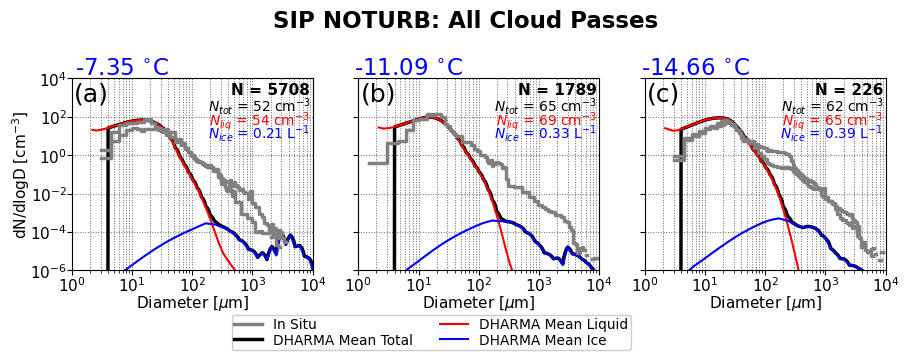

done


In [138]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3.))
axes_flat = np.ndarray.flatten(axes)
Fontsize=11

diam_liq = pc_radius * 2        # native liquid diameters [microns]
diam_ice = pc_radius_ice * 2    # native ice    diameters [microns]

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

left_axes = [axes_flat[0]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')


#========================================================
# All CPs (Loop)
#========================================================
dumi=0
for key in all_cp_dNdlogD_dict.keys():

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                             c='grey', lw=2.5, label='In Situ', where='mid', zorder=1000)

    # Total — interpolated common grid
    dNdlogD_arr  = all_cp_dNdlogD_dict[key]
    dNdD_arr     = all_cp_dNdD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdD    = np.mean(dNdD_arr,    axis=0)

    # Liquid / Ice — raw native grids
    mean_dNdlogD_liq = np.mean(all_cp_dNdlogD_liq_raw_dict[key], axis=0)
    mean_dNdD_liq    = np.mean(all_cp_dNdD_liq_raw_dict[key],    axis=0)
    mean_dNdlogD_ice = np.mean(all_cp_dNdlogD_ice_raw_dict[key], axis=0)
    mean_dNdD_ice    = np.mean(all_cp_dNdD_ice_raw_dict[key],    axis=0)

    N_int     = scipy.integrate.trapezoid(mean_dNdD,     diam_midbins*1.e6)
    N_liq_int = scipy.integrate.trapezoid(mean_dNdD_liq, diam_liq)
    N_ice_int = scipy.integrate.trapezoid(mean_dNdD_ice, diam_ice) * 1.e3

    num_dsds = len(dNdlogD_arr[:,0])

    axes_flat[dumi].plot(diam_midbins*1.e6, mean_dNdlogD,     c='black', lw=2.5, label='DHARMA Mean Total')
    axes_flat[dumi].plot(diam_liq,          mean_dNdlogD_liq, c='red',   lw=1.5, label='DHARMA Mean Liquid')
    axes_flat[dumi].plot(diam_ice,          mean_dNdlogD_ice, c='blue',  lw=1.5, label='DHARMA Mean Ice')

    axes_flat[dumi].text(0.99,0.98,        'N = '+str(int(num_dsds)),                    fontsize=Fontsize,    fontweight='bold', ha='right',va='top',transform=axes_flat[dumi].transAxes)
    axes_flat[dumi].text(0.99,0.98-0.07,   '$N_{tot}$ = '+str(int(N_int))+' cm$^{-3}$', fontsize=Fontsize*0.9,ha='right',va='top',transform=axes_flat[dumi].transAxes,c='k')
    axes_flat[dumi].text(0.99,0.98-0.07*2,'$N_{liq}$ = '+str(int(N_liq_int))+' cm$^{-3}$',fontsize=Fontsize*0.9,ha='right',va='top',transform=axes_flat[dumi].transAxes,c='red')
    axes_flat[dumi].text(0.99,0.98-0.07*3,'$N_{ice}$ = '+str(np.around(N_ice_int,2))+' L$^{-1}$',fontsize=Fontsize*0.9,ha='right',va='top',transform=axes_flat[dumi].transAxes,c='blue')

    dumi+=1

for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#axes_flat[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(2.35,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

# =========================================================
# LEGEND CREATION (THE FIX IS HERE)
# =========================================================
# Get all the handles and labels from the first subplot
handles, labels = axes_flat[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat[0].legend(handles[1:], labels[1:], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(2.35, -0.45), labelspacing=0.1, 
                    borderpad=0.2, ncol=2)

plt.suptitle(cap_sim_name+': All Cloud Passes',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.09,top=0.75)

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

## Updrafts - Means Only

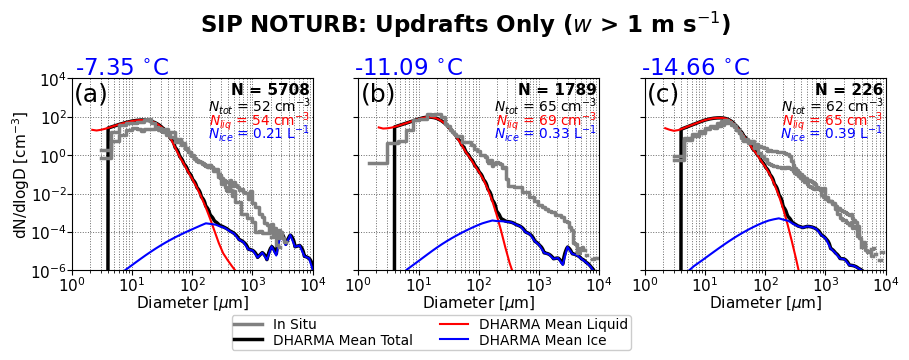

done


In [139]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3.))
axes_flat = np.ndarray.flatten(axes)
Fontsize=11

diam_liq = pc_radius * 2        # native liquid diameters [microns]
diam_ice = pc_radius_ice * 2    # native ice    diameters [microns]

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

left_axes = [axes_flat[0]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')


#========================================================
# All CPs (Loop)
#========================================================
dumi=0
for key in up_w_dNdlogD_dict.keys():

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='grey', lw=2.5, label='In Situ', where='mid', zorder=1000)

    # Total — interpolated common grid
    dNdlogD_arr  = all_cp_dNdlogD_dict[key]
    dNdD_arr     = all_cp_dNdD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    mean_dNdD    = np.mean(dNdD_arr,    axis=0)

    # Liquid / Ice — raw native grids
    mean_dNdlogD_liq = np.mean(all_cp_dNdlogD_liq_raw_dict[key], axis=0)
    mean_dNdD_liq    = np.mean(all_cp_dNdD_liq_raw_dict[key],    axis=0)
    mean_dNdlogD_ice = np.mean(all_cp_dNdlogD_ice_raw_dict[key], axis=0)
    mean_dNdD_ice    = np.mean(all_cp_dNdD_ice_raw_dict[key],    axis=0)

    N_int     = scipy.integrate.trapezoid(mean_dNdD,     diam_midbins*1.e6)
    N_liq_int = scipy.integrate.trapezoid(mean_dNdD_liq, diam_liq)
    N_ice_int = scipy.integrate.trapezoid(mean_dNdD_ice, diam_ice) * 1.e3

    num_dsds = len(dNdlogD_arr[:,0])

    axes_flat[dumi].plot(diam_midbins*1.e6, mean_dNdlogD,     c='black', lw=2.5, label='DHARMA Mean Total')
    axes_flat[dumi].plot(diam_liq,          mean_dNdlogD_liq, c='red',   lw=1.5, label='DHARMA Mean Liquid')
    axes_flat[dumi].plot(diam_ice,          mean_dNdlogD_ice, c='blue',  lw=1.5, label='DHARMA Mean Ice')

    axes_flat[dumi].text(0.99,0.98,        'N = '+str(int(num_dsds)),                    fontsize=Fontsize,    fontweight='bold', ha='right',va='top',transform=axes_flat[dumi].transAxes)
    axes_flat[dumi].text(0.99,0.98-0.07,   '$N_{tot}$ = '+str(int(N_int))+' cm$^{-3}$', fontsize=Fontsize*0.9,ha='right',va='top',transform=axes_flat[dumi].transAxes,c='k')
    axes_flat[dumi].text(0.99,0.98-0.07*2,'$N_{liq}$ = '+str(int(N_liq_int))+' cm$^{-3}$',fontsize=Fontsize*0.9,ha='right',va='top',transform=axes_flat[dumi].transAxes,c='red')
    axes_flat[dumi].text(0.99,0.98-0.07*3,'$N_{ice}$ = '+str(np.around(N_ice_int,2))+' L$^{-1}$',fontsize=Fontsize*0.9,ha='right',va='top',transform=axes_flat[dumi].transAxes,c='blue')

    dumi+=1

for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#axes_flat[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(2.35,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)
# =========================================================
# LEGEND CREATION (THE FIX IS HERE)
# =========================================================
# Get all the handles and labels from the first subplot
handles, labels = axes_flat[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat[0].legend(handles[1:], labels[1:], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(2.35, -0.45), labelspacing=0.1, 
                    borderpad=0.2, ncol=2)
plt.suptitle(cap_sim_name+': Updrafts Only ($w$ > 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.09,top=0.75)

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

## All CPs -- All samples

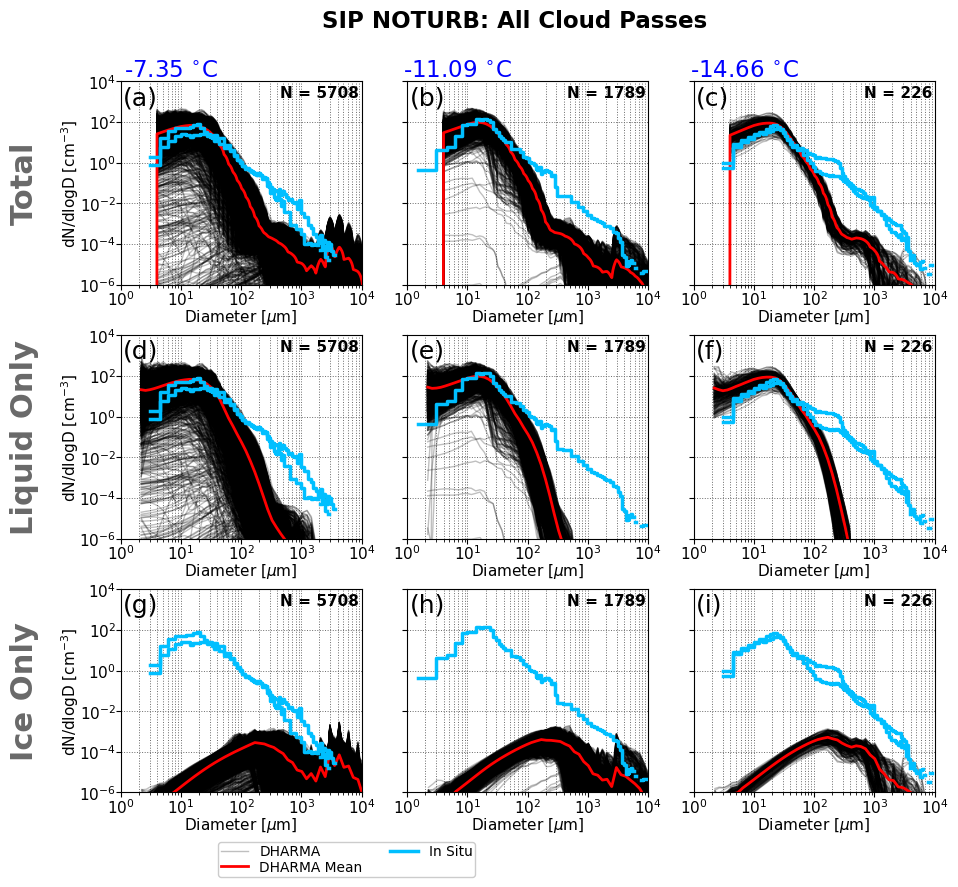

done


In [140]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=3,ncols=n_obs,figsize=(3.5*n_obs, 9),constrained_layout=False)
axes_flat = np.ndarray.flatten(axes)
Fontsize=11

diam_liq = pc_radius * 2
diam_ice = pc_radius_ice * 2

N_SUBSAMPLE = 10000

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

left_axes = [axes_flat[0], axes_flat[n_obs], axes_flat[2*n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]
axes_flat_3 = axes_flat[2*n_obs:]


# --- Row 1: Total (interpolated common grid) ---
dumi=0
for key in all_cp_dNdlogD_dict.keys():
    dNdlogD_arr  = all_cp_dNdlogD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    num_dsds = len(dNdlogD_arr[:,0])
    plot_idx = np.random.choice(num_dsds, min(num_dsds, N_SUBSAMPLE), replace=False) if num_dsds > N_SUBSAMPLE else np.arange(num_dsds)
    for ii, idx in enumerate(plot_idx):
        lbl = 'DHARMA' if ii == 0 else None
        axes_flat_1[dumi].plot(diam_midbins*1.e6, dNdlogD_arr[idx,:], c='k', lw=1, alpha=0.25, label=lbl)
    axes_flat_1[dumi].plot(diam_midbins*1.e6, mean_dNdlogD, c='red', lw=2., label='DHARMA Mean')
    axes_flat_1[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat_1[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    #_obs_src = p3_dict[p3_keys[0]] if key == 'p3' else learjet_dict[key]
    #axes_flat_1[dumi].step(_obs_src['comp']['sizes'], _obs_src['comp']['dNdlogD']*1.e-3, c='deepskyblue', lw=2., label='In Situ', where='mid')
    dumi+=1

# --- Row 2: Liquid — raw native grid ---
dumi=0
for key in all_cp_dNdlogD_liq_raw_dict.keys():
    dNdlogD_arr  = all_cp_dNdlogD_liq_raw_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    num_dsds = len(dNdlogD_arr[:,0])
    plot_idx = np.random.choice(num_dsds, min(num_dsds, N_SUBSAMPLE), replace=False) if num_dsds > N_SUBSAMPLE else np.arange(num_dsds)
    for ii, idx in enumerate(plot_idx):
        lbl = 'DHARMA' if ii == 0 else None
        axes_flat_2[dumi].plot(diam_liq, dNdlogD_arr[idx,:], c='k', lw=1, alpha=0.25, label=lbl)
    axes_flat_2[dumi].plot(diam_liq, mean_dNdlogD, c='red', lw=2., label='DHARMA Mean')
    axes_flat_2[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat_2[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    #_obs_src = p3_dict[p3_keys[0]] if key == 'p3' else learjet_dict[key]
    #axes_flat_2[dumi].step(_obs_src['comp']['sizes'], _obs_src['comp']['dNdlogD']*1.e-3, c='deepskyblue', lw=2., label='In Situ', where='mid')
    dumi+=1

# --- Row 3: Ice — raw native grid ---
dumi=0
for key in all_cp_dNdlogD_ice_raw_dict.keys():
    dNdlogD_arr  = all_cp_dNdlogD_ice_raw_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    num_dsds = len(dNdlogD_arr[:,0])
    plot_idx = np.random.choice(num_dsds, min(num_dsds, N_SUBSAMPLE), replace=False) if num_dsds > N_SUBSAMPLE else np.arange(num_dsds)
    for ii, idx in enumerate(plot_idx):
        lbl = 'DHARMA' if ii == 0 else None
        axes_flat_3[dumi].plot(diam_ice, dNdlogD_arr[idx,:], c='k', lw=1, alpha=0.25, label=lbl)
    axes_flat_3[dumi].plot(diam_ice, mean_dNdlogD, c='red', lw=2., label='DHARMA Mean')
    axes_flat_3[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat_3[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat_3[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    #_obs_src = p3_dict[p3_keys[0]] if key == 'p3' else learjet_dict[key]
    #axes_flat_3[dumi].step(_obs_src['comp']['sizes'], _obs_src['comp']['dNdlogD']*1.e-3, c='deepskyblue', lw=2., label='In Situ', where='mid')
    dumi+=1

for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#axes_flat_3[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)
# =========================================================
# LEGEND CREATION (THE FIX IS HERE)
# =========================================================
# Get all the handles and labels from the first subplot
handles, labels = axes_flat_3[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat_3[0].legend(handles[:-1], labels[:-1], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

plt.suptitle(cap_sim_name+': All Cloud Passes',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.4,0.5,'Total',fontsize=Fontsize*2.,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.4,0.5,'Liquid Only',fontsize=Fontsize*2.,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')
axes_flat_3[0].text(-0.4,0.5,'Ice Only',fontsize=Fontsize*2.,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_3[0].transAxes,c='dimgrey')

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')


## Updrafts only -- All samples

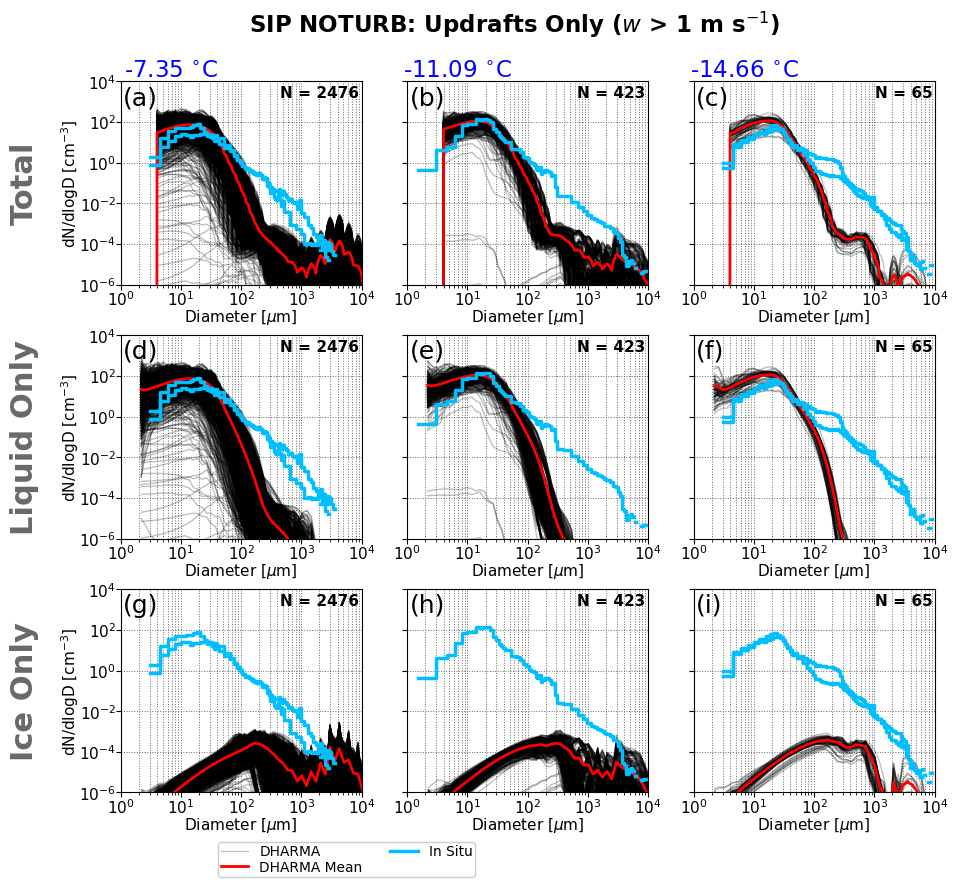

done


In [141]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=3,ncols=n_obs,figsize=(3.5*n_obs, 9),constrained_layout=False)
axes_flat = np.ndarray.flatten(axes)
Fontsize=11

diam_liq = pc_radius * 2
diam_ice = pc_radius_ice * 2

N_SUBSAMPLE = 10000

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

left_axes = [axes_flat[0], axes_flat[n_obs], axes_flat[2*n_obs]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes_flat:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(3*n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')

axes_flat_1 = axes_flat[0:n_obs]
axes_flat_2 = axes_flat[n_obs:2*n_obs]
axes_flat_3 = axes_flat[2*n_obs:]


# --- Row 1: Total (interpolated common grid) ---
dumi=0
for key in up_w_dNdlogD_dict.keys():
    dNdlogD_arr  = up_w_dNdlogD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    num_dsds = len(dNdlogD_arr[:,0])
    plot_idx = np.random.choice(num_dsds, min(num_dsds, N_SUBSAMPLE), replace=False) if num_dsds > N_SUBSAMPLE else np.arange(num_dsds)
    for ii, idx in enumerate(plot_idx):
        lbl = 'DHARMA' if ii == 0 else None
        axes_flat_1[dumi].plot(diam_midbins*1.e6, dNdlogD_arr[idx,:], c='k', lw=1, alpha=0.25, label=lbl)
    axes_flat_1[dumi].plot(diam_midbins*1.e6, mean_dNdlogD, c='red', lw=2., label='DHARMA Mean')
    axes_flat_1[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat_1[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat_1[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    #_obs_src = p3_dict[p3_keys[0]] if key == 'p3' else learjet_dict[key]
    #axes_flat_1[dumi].step(_obs_src['comp']['sizes'], _obs_src['comp']['dNdlogD']*1.e-3, c='deepskyblue', lw=2., label='In Situ', where='mid')
    dumi+=1

# --- Row 2: Liquid — raw native grid ---
dumi=0
for key in up_w_dNdlogD_liq_raw_dict.keys():
    dNdlogD_arr  = up_w_dNdlogD_liq_raw_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    num_dsds = len(dNdlogD_arr[:,0])
    plot_idx = np.random.choice(num_dsds, min(num_dsds, N_SUBSAMPLE), replace=False) if num_dsds > N_SUBSAMPLE else np.arange(num_dsds)
    for ii, idx in enumerate(plot_idx):
        lbl = 'DHARMA' if ii == 0 else None
        axes_flat_2[dumi].plot(diam_liq, dNdlogD_arr[idx,:], c='k', lw=1, alpha=0.25, label=lbl)
    axes_flat_2[dumi].plot(diam_liq, mean_dNdlogD, c='red', lw=2., label='DHARMA Mean')
    axes_flat_2[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat_2[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat_2[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    #_obs_src = p3_dict[p3_keys[0]] if key == 'p3' else learjet_dict[key]
    #axes_flat_2[dumi].step(_obs_src['comp']['sizes'], _obs_src['comp']['dNdlogD']*1.e-3, c='deepskyblue', lw=2., label='In Situ', where='mid')
    dumi+=1

# --- Row 3: Ice — raw native grid ---
dumi=0
for key in up_w_dNdlogD_ice_raw_dict.keys():
    dNdlogD_arr  = up_w_dNdlogD_ice_raw_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr, axis=0)
    num_dsds = len(dNdlogD_arr[:,0])
    plot_idx = np.random.choice(num_dsds, min(num_dsds, N_SUBSAMPLE), replace=False) if num_dsds > N_SUBSAMPLE else np.arange(num_dsds)
    for ii, idx in enumerate(plot_idx):
        lbl = 'DHARMA' if ii == 0 else None
        axes_flat_3[dumi].plot(diam_ice, dNdlogD_arr[idx,:], c='k', lw=1, alpha=0.25, label=lbl)
    axes_flat_3[dumi].plot(diam_ice, mean_dNdlogD, c='red', lw=2., label='DHARMA Mean')
    axes_flat_3[dumi].text(0.99,0.98,'N = '+str(int(num_dsds)),fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat_3[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat_3[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    #_obs_src = p3_dict[p3_keys[0]] if key == 'p3' else learjet_dict[key]
    #axes_flat_3[dumi].step(_obs_src['comp']['sizes'], _obs_src['comp']['dNdlogD']*1.e-3, c='deepskyblue', lw=2., label='In Situ', where='mid')
    dumi+=1

for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#axes_flat_3[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)
# =========================================================
# LEGEND CREATION (THE FIX IS HERE)
# =========================================================
# Get all the handles and labels from the first subplot
handles, labels = axes_flat_3[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat_3[0].legend(handles[:-1], labels[:-1], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

plt.suptitle(cap_sim_name+': Updrafts Only ($w$ > 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.25,top=0.9)

axes_flat_1[0].text(-0.4,0.5,'Total',fontsize=Fontsize*2.,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_1[0].transAxes,c='dimgrey')
axes_flat_2[0].text(-0.4,0.5,'Liquid Only',fontsize=Fontsize*2.,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_2[0].transAxes,c='dimgrey')
axes_flat_3[0].text(-0.4,0.5,'Ice Only',fontsize=Fontsize*2.,fontweight='bold',rotation=90,ha='center',va='center',transform=axes_flat_3[0].transAxes,c='dimgrey')

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')


In [142]:
#print(diam_liq)
#print(diam_ice)
#print(diam_midbins*1.e6)

In [143]:
sim_dict = {}
for key in up_w_dNdlogD_dict.keys():
    sim_dict[key] = {}
    sim_dict[key] = {'up_w_dNdlogD':up_w_dNdlogD_dict[key],\
                     'up_w_dNdD':up_w_dNdD_dict[key],\
                     'up_w_dNdlogD_liq':up_w_dNdlogD_liq_raw_dict[key],\
                     'up_w_dNdD_liq':up_w_dNdD_liq_raw_dict[key],\
                     'up_w_dNdlogD_ice':up_w_dNdlogD_ice_raw_dict[key],\
                     'up_w_dNdD_ice':up_w_dNdD_ice_raw_dict[key],\
                     'all_cp_dNdlogD':all_cp_dNdlogD_dict[key],\
                     'all_cp_dNdD':all_cp_dNdD_dict[key],\
                     'all_cp_dNdlogD_liq':all_cp_dNdlogD_liq_raw_dict[key],\
                     'all_cp_dNdD_liq':all_cp_dNdD_liq_raw_dict[key],\
                     'all_cp_dNdlogD_ice':all_cp_dNdlogD_ice_raw_dict[key],\
                     'all_cp_dNdD_ice':all_cp_dNdD_ice_raw_dict[key],\
                     'diam_tot':diam_midbins*1.e6,\
                     'diam_liq':diam_liq,\
                     'diam_ice':diam_ice,\
                    }

In [144]:
for key,val in sim_dict.items():
    print(key)
    for key2,val2 in val.items():
        print('     ',key2,np.shape(val2))

lj_neg7
      up_w_dNdlogD (2476, 439)
      up_w_dNdD (2476, 439)
      up_w_dNdlogD_liq (2476, 50)
      up_w_dNdD_liq (2476, 50)
      up_w_dNdlogD_ice (2476, 50)
      up_w_dNdD_ice (2476, 50)
      all_cp_dNdlogD (5708, 439)
      all_cp_dNdD (5708, 439)
      all_cp_dNdlogD_liq (5708, 50)
      all_cp_dNdD_liq (5708, 50)
      all_cp_dNdlogD_ice (5708, 50)
      all_cp_dNdD_ice (5708, 50)
      diam_tot (439,)
      diam_liq (50,)
      diam_ice (50,)
p3_neg11
      up_w_dNdlogD (423, 439)
      up_w_dNdD (423, 439)
      up_w_dNdlogD_liq (423, 50)
      up_w_dNdD_liq (423, 50)
      up_w_dNdlogD_ice (423, 50)
      up_w_dNdD_ice (423, 50)
      all_cp_dNdlogD (1789, 439)
      all_cp_dNdD (1789, 439)
      all_cp_dNdlogD_liq (1789, 50)
      all_cp_dNdD_liq (1789, 50)
      all_cp_dNdlogD_ice (1789, 50)
      all_cp_dNdD_ice (1789, 50)
      diam_tot (439,)
      diam_liq (50,)
      diam_ice (50,)
lj_neg15
      up_w_dNdlogD (65, 439)
      up_w_dNdD (65, 439)
      up_w_dNdlog

In [145]:
save_path = '/pscratch/sd/m/mckenna/dharma_post/'
file_name = save_path+sim_name+'_cloud_pass_dict.p'
pickle.dump(sim_dict,open(file_name,"wb")) 